# Imports

In [13]:
# imports
import numpy as np
import warnings
import os

import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p/"src").is_dir())))

# Alignment models
from src.mali import MALI
from src.fosta import FoSTA
from src.fosta_icml import FoSTA as FoSTA_ICML
from src.kemalin import KEMAlin
from src.kemarbf import KEMArbf
from src.pamona import Pamona
from src.upamona import UPamona
from src.jointmds import JointMDS

from utils.tree_utils import gen_tree

from phate import PHATE # We need the base PHATE class for the final step
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox # For image plotting
from scipy import sparse
import seaborn as sns

from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Evaluation metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score
from src.Pamona.eval import calc_domainAveraged_FOSCTTM

# utils
from utils.utils import load_paired_mnist_rotated, load_paired_mnist_sensor_defect



# Silence harmless warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


# Hyperparameters

In [14]:
model_name = "FoSTA"  # "FoSTA", "MALI", "KEMA", "JPamona", "Pamona", "UPamona", "JointMDS"
embedder = "PHATE"  # "PHATE", "UMAP", 'spectral'


mu = 1
propagate = True  # FoSTA only
dpt = False  # FoSTA only (whether to use diffusion pseudotime for the alignment instead of the original data)
force_nonzero_diag = True  # For old version of FoSTA only (should we add a small constant to the diagonal of the kernel to ensure it's nonzero, as in MALI?)
normalize_diagonal = True
force_symmetric = True
kernel_method = 'gap'
model_type = 'rf'
t = 'auto'  # For PHATE embedders in MALI and RFMALI and FoSTA
beta = 0.7  # For PHATE embedders in MALI and RFMALI and FoSTA
n_estimators = 100  # Number of trees in RF
prior_correct = True  # For FoSTA only (should we reweight the semantic vectors by the inverse class frequencies to correct for imbalanced labels?)


# 'new' FoSTA only
l2_normalize = True  # For FoSTA only (should we l2 normalize semantic vectors after prior correction?)
ot_solver = 'hiref'


# t_sem_a = 0  # For FoSTA only (should we diffuse the semantic vectors before using them for alignment?)
# t_sem_b = 0  # For FoSTA only (should we diffuse the semantic vectors before using them for alignment?)
# average_semantic_diffusion = True  # For FoSTA only (if True, average the semantic vectors across all diffusion scales up to t_sem instead of just taking the final one)



# OLD FoSTA only
# force_nonzero_diag=False
# normalize_diagonal = False  # whether to normalize by the diagonal of the kernel (self-similarity) to make the diagonal entries 1.0 (as in MALI) or to keep the original scale (as in original RF-GAP)




gamma = 0.5  # For JPamona only (supervision strength for OT)





# --- TOGGLE THIS TO SWITCH DATASETS ---
DATASET_NAME = "tree"  # Options: "tree", "digits", "single_cell"
# --------------------------------------

# Experiment Parameters
seed = 422222
n_noise = 100      # Noise features for Target  (Tree dataset only)
frac_labeled = 0.5   # Semi-supervised labels
remove_p_target = 0 # Imbalance (Remove % of target)

# Generate two artifical with 10 branches (fully labeled): source tree is clean, target has additional 1000 uniform (0,1) noise features.

In [15]:
import scanpy as sc
from scipy import sparse
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit

print(f"=== Generating Paired Dataset: {DATASET_NAME} ===")

if DATASET_NAME == "tree":
    # 1000 samples total
    x_source, y_source, _ = gen_tree(n_branch=10, n_child=2, n_dim_per_branch=4, branch_length=100, seed=seed, sigma=7, merged_branch=False)
    x_target, y_target, _ = gen_tree(n_branch=10, n_child=2, n_dim_per_branch=16, branch_length=100, seed=seed, sigma=7, merged_branch=False)

elif DATASET_NAME == "digits":
    # 1500 samples total
    x_source, y_source, x_target, y_target = load_paired_mnist_sensor_defect(
        n_samples=1000, seed=seed)

# === NEW BLOCK: SINGLE CELL (Hard Mode) ===
elif DATASET_NAME == "single_cell":
    # 1. Load Data (PBMC 3k)
    adata = sc.datasets.pbmc3k_processed()
    
    # 2. Subsample to fixed size (e.g. 1000)
    # Note: We use the SAME cells for x_source and x_target initially 
    # so that T_true = Identity is valid.
    target_n = 5000
    if adata.n_obs > target_n:
        sc.pp.subsample(adata, n_obs=target_n, random_state=seed)
    
    # 3. Prepare Source (Reference)
    x_source = adata.X
    if sparse.issparse(x_source): x_source = x_source.toarray()
    
    # Convert string labels to integers for consistency
    y_source = adata.obs['louvain'].cat.codes.values 
    
    # 4. Prepare Target (Perturbed)
    # Start with exact copy (paired)
    x_target = x_source.copy()
    y_target = y_source.copy()
    
    # --- Apply "Hard Mode" Perturbations ---
    rng_sc = np.random.RandomState(seed)
    n_features = x_source.shape[1]
    
    # A. Uniform Rotation (Geometry Mismatch)
    # We generate a random orthogonal matrix Q via QR decomposition of a random matrix.
    # This rotates the entire dataset rigidly, preserving internal structure but shifting axes.
    random_matrix = rng_sc.randn(n_features, n_features)
    Q, _ = np.linalg.qr(random_matrix)
    x_target = x_target @ Q
    
    # B. Non-linear Warping (Amplification Bias)
    x_target = np.sign(x_target) * np.power(np.abs(x_target), 1.2)
    
    # C. Depth Scaling (Sparsity)
    x_target = x_target * 0.5
    
    print(f"Loaded Single Cell (PBMC3k): {x_source.shape} features")
    print("Applied Rotation, Warping (pow 1.2), and Scaling (0.5) to Target.")

# --- INITIALIZE TRUE COUPLING ---
# Since data is paired (Sample i in Source == Sample i in Target), 
# T_true starts as Identity.
n_samples = len(x_source)
T_true = np.eye(n_samples) 

print(f"Initial Shapes: Source {x_source.shape}, Target {x_target.shape}")
print(f"T_true Initialized: {T_true.shape} (Identity)")

# 1. Normalization
# SKIP MinMax for single_cell to preserve the specific density perturbations
if DATASET_NAME != "single_cell":
    x_source = MinMaxScaler().fit_transform(x_source)
    x_target = MinMaxScaler().fit_transform(x_target)

# 2. Add Noise Features to Target
if n_noise > 0:
    rng = np.random.RandomState(seed)
    noise_feats = rng.rand(x_target.shape[0], n_noise)
    x_target = np.hstack([x_target, noise_feats])

# 3. Semi-Supervised Masking
if frac_labeled >= 1.0:
    y_target_true = y_target.copy() 
    print("Using all labels.")
else:
    print(f"Masking labels ({frac_labeled:.1%} visible)...")
    # Backup true labels for evaluation later
    y_target_true = y_target.copy() 
    
    # Masking logic
    y_target = np.asarray(y_target).copy()
    sss = StratifiedShuffleSplit(n_splits=1, train_size=frac_labeled, random_state=seed)
    try:
        labeled_idx, unlabeled_idx = next(sss.split(np.zeros(len(y_target)), y_target))
        y_target[unlabeled_idx] = -1
    except ValueError:
        mask = np.random.rand(len(y_target)) > frac_labeled
        y_target[mask] = -1

# 4. Random Removal (Imbalance) & UPDATE T_TRUE
# ---------------------------------------------------------
mask_missing_target_full = (y_target == -1)  # before removal, length nB
if remove_p_target > 0:
    rng_remove = np.random.RandomState(seed)
    nB = len(y_target)
    n_keep = int(np.round((1.0 - remove_p_target) * nB))
    
    # Indices to keep in Target
    keep_idx = rng_remove.choice(nB, size=n_keep, replace=False)
    keep_idx = np.sort(keep_idx)
    
    # Apply to Data
    x_target = x_target[keep_idx]
    y_target = y_target[keep_idx]
    y_target_true = y_target_true[keep_idx] # Keep backup synced
    
    # Apply to T_true
    # T_true maps Source (Rows) -> Target (Cols)
    # We removed columns from Target, so we slice columns of T_true
    T_true = T_true[:, keep_idx]

    mask_missing_target_full = mask_missing_target_full[keep_idx]  # keep mask synced
    
    print(f"Imbalance Applied: Removed {nB - n_keep} target samples.")
    print(f"New Target Shape: {x_target.shape}")
    print(f"New T_true Shape: {T_true.shape}")

=== Generating Paired Dataset: tree ===
Initial Shapes: Source (1000, 40), Target (1000, 160)
T_true Initialized: (1000, 1000) (Identity)
Masking labels (50.0% visible)...


# Model training and alignment

In [16]:
if model_name == "FoSTA":
    model = FoSTA(
        embedder=embedder,

        mu=mu,
        propagate=propagate,
        dpt=dpt,


        normalize_diagonal=normalize_diagonal,
        force_nonzero_diag=force_nonzero_diag,
        force_symmetric=force_symmetric,
        l2_normalize=l2_normalize,


        n_components=2,


        # t_sem_a=t_sem_a,
        # t_sem_b=t_sem_b,
        # average_semantic_diffusion=average_semantic_diffusion,


        prior_correct=prior_correct,
        kernel_method=kernel_method,
        model_type=model_type,

        ot_solver=ot_solver,

        n_estimators=n_estimators,
        t=t,
        beta=beta,
        random_state=seed,
        n_jobs=-1,
        verbose=1,
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")

if model_name == "FoSTA_ICML":
    model = FoSTA_ICML(
        embedder=embedder,
        n_components=2,
        t=t,
        random_state=seed
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")

elif model_name == 'MALI':
    model = MALI(embedder=embedder,
                 n_components=2,
                 beta=beta,
                 t=t,
                 verbose=1,
                 random_state=seed)
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'KEMArbf':
    model = KEMArbf(
        n_components=2,
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'KEMAlin':
    model = KEMAlin(
        n_components=2,
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'JointMDS':
    model = JointMDS()
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'UPamona':
    model = UPamona(
        n_components=2,
        embedder=embedder,
        random_state=seed
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'Pamona':
    model = Pamona(
        n_components=2,
        embedder=embedder,
        gamma=gamma,  # controls supervision strength, 1=fully supervised
        random_state=seed
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")


Starting alignment...

[Domain A] Fitting forest on labeled points...
[Domain A] OOB classification acc.: 0.8700
[Domain A] Computing FoSTA kernel (full NxN)...
[Domain A] Shapes: prox=(1000, 1000) | NNZ density=0.192466

[Domain B] Fitting forest on labeled points...
[Domain B] OOB classification acc.: 0.6100
[Domain B] Computing FoSTA kernel (full NxN)...
[Domain B] Shapes: prox=(1000, 1000) | NNZ density=0.537320
[Domain A] Semantic row sums before prior correction and l2 normalization: min=3.561896, mean=11.884990, max=29.329044
[Domain B] Semantic row sums before prior correction and l2 normalization: min=2.530658, mean=3.686330, max=5.635220
[FoSTA] Coupling selected points: A=1000/1000, B=1000/1000, mode=predict_shared
Optimized rank-annealing schedule: [1000]
HiRef: Aligning A(1000) and B(1000). Target square size: 1000
Optimized rank-annealing schedule: [1000]

JOINT AFFINITY BLOCK STATISTICS (cross-domain propagation=True):
------------------------------

Within-domain A (W1

# Visualize affinity matrices

In [17]:
# # prox_mat = model.W.toarray() if sparse.issparse(model.W) else model.W
# W = model.W

# # truncate to get the first 1000x1000 block for better visualization
# W = W[:1000, :1000]



# W = model.prox_a


# prox_mat = W.toarray() if sparse.issparse(W) else W

# # Set diag to zero
# # prox_mat[np.diag_indices_from(prox_mat)] = 0.0


# # mask diagonal to emphasize off-diagonal proximities
# mask=None

# fig, ax = plt.subplots(figsize=(10, 10))
# sns.heatmap(prox_mat, ax=ax, cmap='rocket_r', vmin=0, vmax=prox_mat.max(),
#             mask=mask,
#             xticklabels=False, yticklabels=False, square=True, cbar_kws={'label': 'Proximity'})
# ax.set_title(f'Affinity Matrix')
# plt.show()




# # Is it symmetric ?
# print("Symmetry Check (W vs W^T):", np.allclose(prox_mat, prox_mat.T, atol=1e-5))

# # Row-wise and Column-wise sums, and diagonal entries
# row_sums = prox_mat.sum(axis=1)
# col_sums = prox_mat.sum(axis=0)
# print("Row sums", row_sums[:5])
# print("Column sums", col_sums[:5])
# print("Diagonal entries", np.diag(prox_mat)[:5])


# # Check Domain A (mostly labeled) vs Domain B (mostly unlabeled)
# diag_a = model.prox_a.diagonal()
# diag_b = model.prox_b.diagonal()

# print(f"Domain A (Source) Mean Diag: {np.mean(diag_a):.4f}")
# print(f"Domain B (Target) Mean Diag: {np.mean(diag_b):.4f}")
# # print the max diagonal entries for each domain to check
# print(f"Domain A (Source) Max Diag: {np.max(diag_a):.4f}")
# print(f"Domain B (Target) Max Diag: {np.max(diag_b):.4f}")
# # print max values in the proximity matrix to check scale in each domain
# print(f"Domain A (Source) Max Proximity: {np.max(model.prox_a):.4f}")
# print(f"Domain B (Target) Max Proximity: {np.max(model.prox_b):.4f}")



# Plot


--- Visualization ---
Data Check: Source=1000, Target=1000 | Embedding shape=(2000, 2)
  Plotted 50 matching lines.


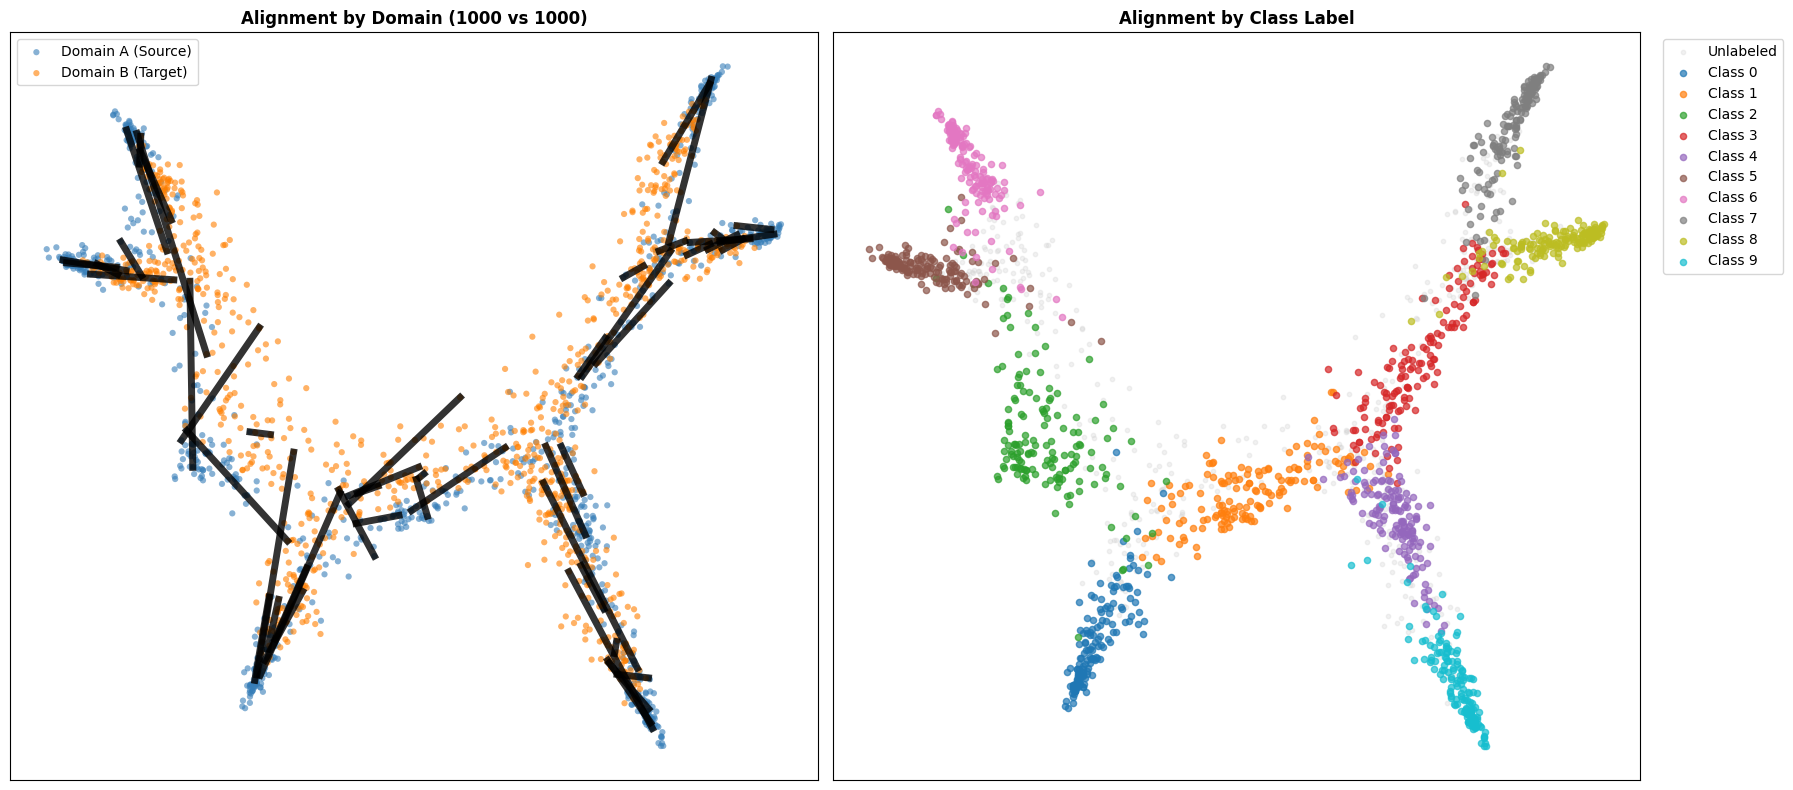

FOSCTTM: 0.0947
Transfer acc on MASKED target labels: 0.562
(Optional) acc on VISIBLE target labels: 0.9
Domain Mixing (Lower is better): 0.0132


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score
from utils.metrics import label_transfer_accuracy

# ------------------------------------
# VISUALIZATION (Robust to Uneven Sizes)
# ------------------------------------
print("\n--- Visualization ---")

# 1. SETUP & SIZE CHECKS
# ------------------------------------
# Ensure we are working with flat arrays
y_source_vis = np.array(y_source).flatten()
y_target_vis = np.array(y_target).flatten()

n_a = len(y_source_vis)
n_b = len(y_target_vis)
n_total_labels = n_a + n_b
n_total_embed = embedding.shape[0]

print(f"Data Check: Source={n_a}, Target={n_b} | Embedding shape={embedding.shape}")

# Safety Fix: If embedding doesn't match labels (e.g. stale variables), we stop to prevent weird plots
if n_total_embed != n_total_labels:
    print(f"(!) CRITICAL WARNING: Embedding has {n_total_embed} points but labels have {n_total_labels}.")
    print("    Adjusting logic to fit the SMALLER size to avoid crash.")
    min_len = min(n_total_embed, n_total_labels)
    # Truncate to safe limit for plotting purposes
    labels_combined = np.concatenate([y_source_vis, y_target_vis])[:min_len]
    embedding_vis = embedding[:min_len]
    
    # Re-calculate split point for domains
    # We assume Source is first. If Source is larger than min_len, Source gets cut.
    # Ideally, this shouldn't happen if code is run in order.
    real_n_a = min(n_a, min_len)
    real_n_b = min_len - real_n_a
else:
    labels_combined = np.concatenate([y_source_vis, y_target_vis]).astype(int)
    embedding_vis = embedding
    real_n_a = n_a
    real_n_b = n_b

# Create Domain Labels
domains_combined = np.concatenate([
    np.full(real_n_a, "Domain A (Source)"),
    np.full(real_n_b, "Domain B (Target)")
])



# 2. GENERATE PLOTS
# ------------------------------------
plt.figure(figsize=(18, 8))

# === PLOT 1: ALIGNMENT BY DOMAIN ===
ax1 = plt.subplot(1, 2, 1)

domain_colors = {"Domain A (Source)": "#377eb8", "Domain B (Target)": "#ff7f00"}
for domain, color in domain_colors.items():
    idx = (domains_combined == domain)
    if np.sum(idx) > 0:
        ax1.scatter(
            embedding_vis[idx, 0], embedding_vis[idx, 1],
            c=color, label=domain, alpha=0.6, s=20, edgecolors='none'
        )

# --- MATCHING LINES (ROBUST VERSION) ---
try:
    if 'T_true' in locals() and T_true is not None:
        T_vis = T_true
        if sparse.issparse(T_vis): T_vis = T_vis.toarray()
        
        # KEY FIX: Adjust T_true to match removed samples
        # If we have 'keep_idx' (indices of targets kept), we must slice T_true columns
        if 'keep_idx' in locals() and len(keep_idx) == real_n_b:
             if T_vis.shape[1] > len(keep_idx):
                 print(f"  Adjusting T_true columns using keep_idx...")
                 T_vis = T_vis[:, keep_idx]
        
        # Fallback: If shape still mismatches, slice strictly by dimensions
        if T_vis.shape != (real_n_a, real_n_b):
            print(f"  (!) T_true shape {T_vis.shape} != Data {(real_n_a, real_n_b)}. Slicing to fit.")
            T_vis = T_vis[:real_n_a, :real_n_b]

        # Draw Lines
        # Calculate row sums to see which Source samples actually match a REMAINING Target
        row_sums = T_vis.sum(axis=1)
        valid_sources = np.where(row_sums > 0.001)[0] # Tolerance for float
        
        # Limit to 50 lines
        if len(valid_sources) > 50:
            np.random.seed(seed)  # For reproducibility
            plot_indices = np.random.choice(valid_sources, 50, replace=False)
        else:
            plot_indices = valid_sources

        line_count = 0
        for i in plot_indices:
            j = np.argmax(T_vis[i, :]) # Best match index in the NEW target set
            
            # Final bounds check
            if i < real_n_a and j < real_n_b:
                x1, y1 = embedding_vis[i]
                x2, y2 = embedding_vis[real_n_a + j]
                ax1.plot([x1, x2], [y1, y2], c='black', alpha=0.8, linewidth=5)
                line_count += 1
                
        print(f"  Plotted {line_count} matching lines.")

except Exception as e:
    print(f"(!) Could not plot matching lines: {e}")

ax1.set_title(f"Alignment by Domain ({real_n_a} vs {real_n_b})", fontweight="bold")
ax1.legend()
ax1.set_xticks([]); ax1.set_yticks([])


# === PLOT 2: ALIGNMENT BY LABEL ===
ax2 = plt.subplot(1, 2, 2)

# Handle -1 (Unlabeled) vs Known Classes
mask_labeled = labels_combined != -1
mask_unlabeled = labels_combined == -1

# Background: Unlabeled
if np.any(mask_unlabeled):
    ax2.scatter(
        embedding_vis[mask_unlabeled, 0], embedding_vis[mask_unlabeled, 1],
        c='lightgrey', label='Unlabeled', alpha=0.3, s=10
    )

# Foreground: Labeled
if np.any(mask_labeled):
    unique_classes = np.unique(labels_combined[mask_labeled])
    cmap = plt.get_cmap("tab10")

    for i, lbl in enumerate(unique_classes):
        idx = (labels_combined == lbl)
        ax2.scatter(
            embedding_vis[idx, 0], embedding_vis[idx, 1],
            color=cmap(i % 10), label=f"Class {lbl}", alpha=0.7, s=20
        )

ax2.set_title("Alignment by Class Label", fontweight="bold")
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.set_xticks([]); ax2.set_yticks([])

plt.tight_layout()
plt.show()


# ------------------------------------
# METRICS (Label transfer)
# ------------------------------------
try:

    # after alignment + embedding
    n_a = len(y_source)          # source was not removed in your snippet
    n_b = len(y_target)          # target after removal
    
    res = label_transfer_accuracy(
        embedding=embedding,                 # shape (n_a + n_b, d)
        n_a=n_a,
        y_source=y_source,                   # shape (n_a,)
        y_target_obs=y_target,               # shape (n_b,) with -1 for masked
        y_target_true=y_target_true,         # shape (n_b,) ground truth (post-removal)
        mask_missing_target=mask_missing_target_full,  # shape (n_b,) post-removal
    )

    if n_a == n_b:
        X_a = embedding_vis[:real_n_a, :]                 # (n_a, d)
        X_b = embedding_vis[real_n_a:real_n_a+real_n_b, :]# (n_b, d)
        foscttm_vals = calc_domainAveraged_FOSCTTM(X_a, X_b)
        foscttm = float(np.mean(foscttm_vals))
        
        print(f"FOSCTTM: {foscttm:.4f}")
    
    print(f"Transfer acc on MASKED target labels: {res['acc_missing']}")
    print(f"(Optional) acc on VISIBLE target labels: {res['acc_visible']}")


    # Domain mixing unchanged
    sil_dom = silhouette_score(embedding_vis, domains_combined)
    print(f"Domain Mixing (Lower is better): {sil_dom:.4f}")

except Exception as e:
    print(f"Metrics error: {e}")